<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/BasicML/BasicML/Feature_Engineering_from_OHLC_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# --- 1. DATA LOADING ---
ticker = 'NVDA' # High volatility stocks work best for this demo
df = yf.download(ticker, start='2020-01-01', end='2024-01-01', progress=False)

# Clean MultiIndex if necessary
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

/tmp/ipython-input-640026107.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2020-01-01', end='2024-01-01', progress=False)


In [ ]:
# --- 2. FEATURE ENGINEERING FUNCTION ---
def generate_ohlc_features(data):
    df = data.copy()

    # --- A. LOG RETURNS (The Baseline) ---
    df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))

    # --- B. CANDLESTICK GEOMETRY (The "Story") ---
    # 1. Body Size: Absolute difference between Open and Close
    # Large body = Strong conviction. Small body = Indecision.
    df['Body_Size'] = abs(df['Close'] - df['Open'])

    # 2. Upper Shadow (Wick): High - max(Open, Close)
    # Long upper shadow = Price rejection at the top (Bearish)
    df['Upper_Shadow'] = df['High'] - df[['Open', 'Close']].max(axis=1)

    # 3. Lower Shadow (Wick): min(Open, Close) - Low
    # Long lower shadow = Price rejection at the bottom (Bullish)
    df['Lower_Shadow'] = df[['Open', 'Close']].min(axis=1) - df['Low']

    # 4. Close Location Value (CLV): Where did we close relative to the range?
    # +1 = Closed at High, -1 = Closed at Low, 0 = Middle
    # Formula: ((C - L) - (H - C)) / (H - L)
    df['CLV'] = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low'])

    # --- C. VOLATILITY (Range-Based) ---
    # 1. True Range (ATR Basis): Max of (H-L), (H-PrevC), (PrevC-L)
    # This captures gaps overnight.
    df['High_Low'] = df['High'] - df['Low']
    df['High_PrevClose'] = abs(df['High'] - df['Close'].shift(1))
    df['Low_PrevClose'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['High_Low', 'High_PrevClose', 'Low_PrevClose']].max(axis=1)
    df['ATR_14'] = df['TR'].rolling(14).mean()

    # 2. Garman-Klass Volatility (Advanced)
    # A far more efficient estimator of volatility than simple Stdev of returns.
    # It uses Open, High, Low, and Close.
    # Formula: 0.5 * ln(H/L)^2 - (2*ln(2) - 1) * ln(C/O)^2
    log_hl = np.log(df['High'] / df['Low'])
    log_co = np.log(df['Close'] / df['Open'])
    df['Garman_Klass_Vol'] = np.sqrt(0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2)

    # --- D. TARGET (Next Day Direction) ---
    df['Target_Next_Ret'] = df['Log_Ret'].shift(-1)
    df['Target_Class'] = np.where(df['Target_Next_Ret'] > 0, 1, 0)

    return df.dropna()

# Apply the function
df_features = generate_ohlc_features(df)

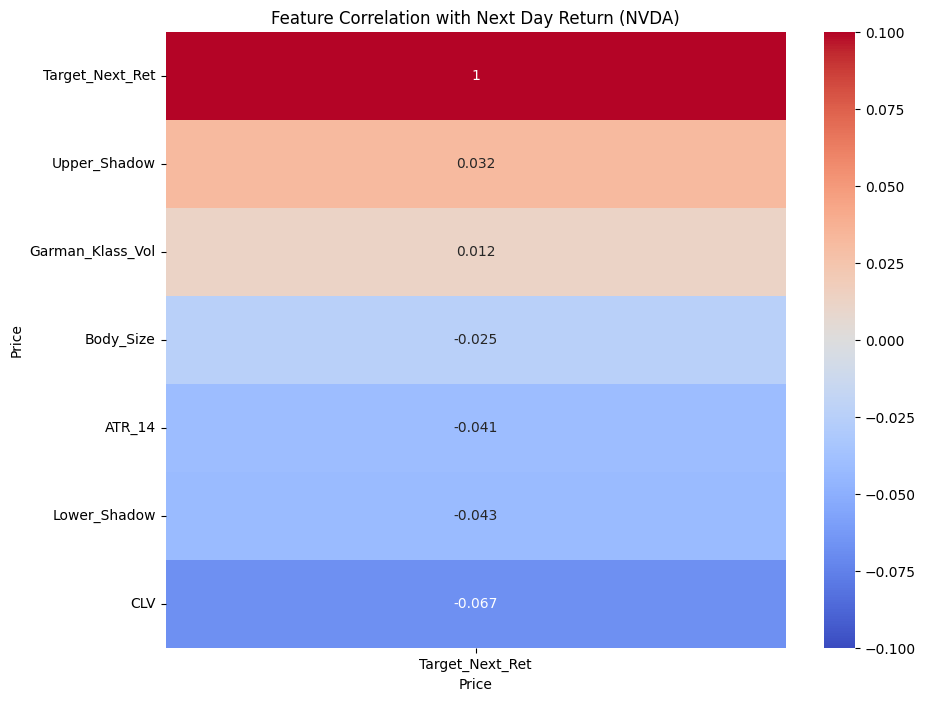

In [ ]:
# --- 3. ANALYSIS: DO THESE FEATURES MATTER? ---
# We check the correlation of these new features with the NEXT DAY'S return.
# A higher absolute correlation means more predictive power.

corr_matrix = df_features[['Target_Next_Ret', 'Body_Size', 'Upper_Shadow', 'Lower_Shadow', 'CLV', 'Garman_Klass_Vol', 'ATR_14']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix[['Target_Next_Ret']].sort_values(by='Target_Next_Ret', ascending=False),
            annot=True, cmap='coolwarm', vmin=-0.1, vmax=0.1)
plt.title(f"Feature Correlation with Next Day Return ({ticker})")
plt.show()

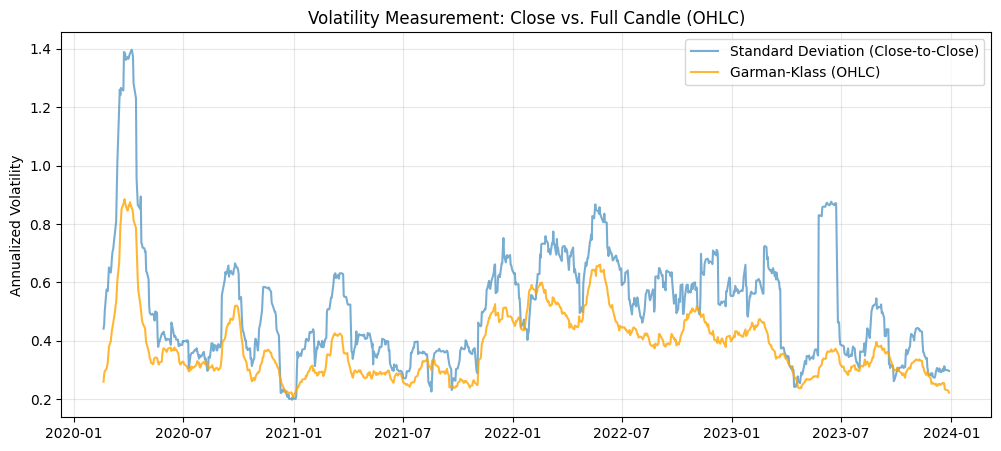

In [ ]:
# --- 4. VISUALIZING GARMAN-KLASS VS STANDARD VOLATILITY ---
# Let's prove why OHLC volatility is better.
rolling_std = df_features['Log_Ret'].rolling(20).std() * np.sqrt(252) # Annualized
gk_vol_smooth = df_features['Garman_Klass_Vol'].rolling(20).mean() * np.sqrt(252)

plt.figure(figsize=(12, 5))
plt.plot(rolling_std, label='Standard Deviation (Close-to-Close)', alpha=0.6)
plt.plot(gk_vol_smooth, label='Garman-Klass (OHLC)', alpha=0.8, color='orange')
plt.title("Volatility Measurement: Close vs. Full Candle (OHLC)")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- 1. DATA LOADING ---
ticker = 'TSLA'  # TSLA is perfect for gaps and volatility
df = yf.download(ticker, start='2019-01-01', end='2024-01-01', progress=False)
if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

/tmp/ipython-input-46180648.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2019-01-01', end='2024-01-01', progress=False)


In [ ]:
# --- 2. ADVANCED FEATURE ENGINEERING FUNCTION ---
def generate_advanced_features(data, window=20):
    df = data.copy()

    # --- A. YANG-ZHANG VOLATILITY (The comprehensive estimator) ---
    # Formula: V_YZ = V_Overnight + k * V_OpenClose + (1-k)*V_RS
    # It requires calculating variances of different components separately.

    # 1. Overnight Volatility (Close to Open)
    # log(O_t / C_t-1)
    df['log_oc'] = np.log(df['Open'] / df['Close'].shift(1))
    # Variance of this over the window
    var_overnight = df['log_oc'].rolling(window).var()

    # 2. Open-to-Close Volatility (Intraday)
    # log(C_t / O_t)
    df['log_co'] = np.log(df['Close'] / df['Open'])
    var_open_close = df['log_co'].rolling(window).var()

    # 3. Rogers-Satchell Volatility (Drift Independent Intraday)
    # This captures the High/Low structural volatility
    # RS = log(H/C)*log(H/O) + log(L/C)*log(L/O)
    log_ho = np.log(df['High'] / df['Open'])
    log_lo = np.log(df['Low'] / df['Open'])
    log_hc = np.log(df['High'] / df['Close'])
    log_lc = np.log(df['Low'] / df['Close'])

    rs_term = log_hc * log_ho + log_lc * log_lo
    var_rs = rs_term.rolling(window).mean()

    # 4. Combine them (k=0.34 is standard for optimal weighting)
    k = 0.34
    # The actual formula sums the variances. We take sqrt at the end.
    df['Yang_Zhang_Vol'] = np.sqrt(var_overnight + k * var_open_close + (1 - k) * var_rs)
    # Annualize it
    df['Yang_Zhang_Vol'] = df['Yang_Zhang_Vol'] * np.sqrt(252)

    # --- B. KAUFMAN EFFICIENCY RATIO (Fractal Efficiency) ---
    # Direction / Volatility
    # Direction = Abs(Price_t - Price_t-n)
    # Volatility = Sum(Abs(Price_t - Price_t-1)) over n days

    change_n = abs(df['Close'] - df['Close'].shift(window))
    daily_change = abs(df['Close'] - df['Close'].shift(1))
    volatility_sum = daily_change.rolling(window).sum()

    df['KER'] = change_n / volatility_sum
    # KER -> 1 means extremely efficient trend. KER -> 0 means chopping sideways.

    # --- C. GAP FEATURES ---
    # Normalized Gap: Gap size relative to daily volatility
    # This tells us if a gap is "significant" or just noise.
    # Note: We use ATR (Average True Range) to normalize
    tr1 = df['High'] - df['Low']
    tr2 = abs(df['High'] - df['Close'].shift(1))
    tr3 = abs(df['Low'] - df['Close'].shift(1))
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(window).mean()

    gap_raw = df['Open'] - df['Close'].shift(1)
    df['Gap_Norm'] = gap_raw / atr

    # Gap Fade Potential: Distance from Open to Close (Intraday move) relative to Gap
    # If Gap is +2% and Close is -1% from Open, we "faded" the gap.
    df['Gap_Fade'] = (df['Close'] - df['Open']) / (df['Open'] - df['Close'].shift(1))

    # Cleanup intermediate columns
    cols_to_drop = ['log_oc', 'log_co', 'Gap_Norm', 'Gap_Fade'] # Keeping main ones for viz
    # We keep 'Gap_Norm' and 'KER' for plotting

    return df.dropna()

# Apply
df_adv = generate_advanced_features(df)

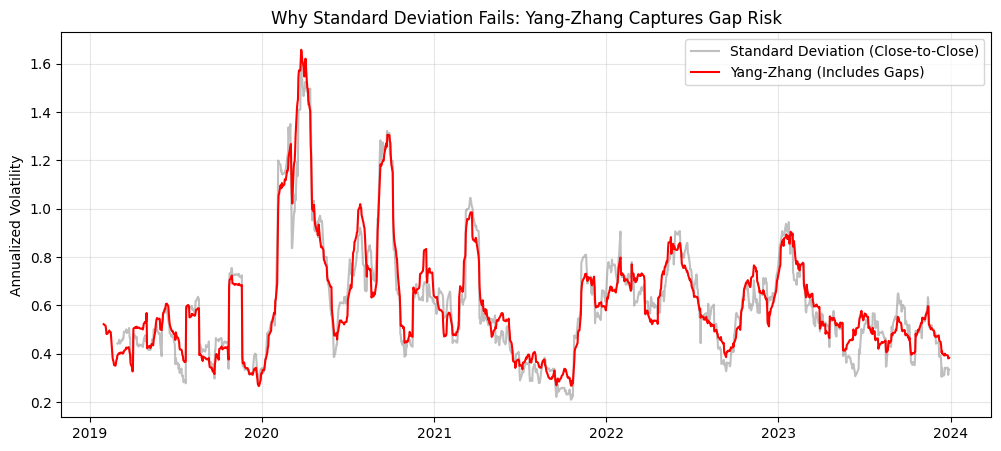

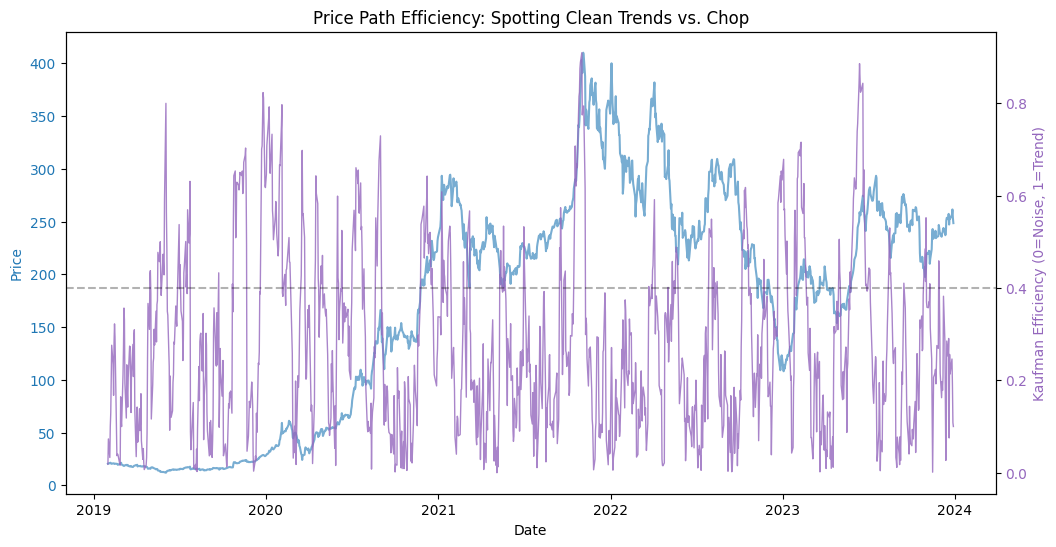

In [ ]:
# --- 3. VISUALIZATION ---

# Plot 1: Standard Volatility vs Yang-Zhang (The "Hidden Risk")
std_vol = df_adv['Close'].pct_change().rolling(20).std() * np.sqrt(252)

plt.figure(figsize=(12, 5))
plt.plot(std_vol, label='Standard Deviation (Close-to-Close)', alpha=0.5, color='gray')
plt.plot(df_adv['Yang_Zhang_Vol'], label='Yang-Zhang (Includes Gaps)', color='red', linewidth=1.5)
plt.title("Why Standard Deviation Fails: Yang-Zhang Captures Gap Risk")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Efficiency Ratio (KER)
# Let's see when the trend was "Clean" vs "Choppy"
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Price', color=color)
ax1.plot(df_adv.index, df_adv['Close'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:purple'
ax2.set_ylabel('Kaufman Efficiency (0=Noise, 1=Trend)', color=color)
ax2.plot(df_adv.index, df_adv['KER'], color=color, alpha=0.8, linewidth=1)
ax2.tick_params(axis='y', labelcolor=color)
# Add a threshold line for "Trending"
ax2.axhline(0.4, color='black', linestyle='--', alpha=0.3, label='Trend Threshold')

plt.title("Price Path Efficiency: Spotting Clean Trends vs. Chop")
plt.show()